In [1]:
from data_prep import *

In [2]:
df = load_data()

no of cols =41


#####  critical date 20131031, 20120629

In [3]:
data = extract_clean_data(df,'c',20131031)

In [4]:
data.head()

,Ticker,TradeDate,ExpiryDate,CallPut,AdjStrike,Strike,AdjSpot,Spot,Month_To_Expiry,days_to_expiry,...,risk_free_rate_4,risk_free_rate_8,risk_free_rate_13,risk_free_rate_17,risk_free_rate_26,risk_free_rate_52,px,risk_free_rate,ImpliedVolatility,time_to_exp
155,AAPL,20131031,20150117,c,13.21,370.0,18.67,522.7,15,443,...,0.0003,NaN,0.0004,NaN,0.0008,0.0009,5.6010,0.000900,0.218882,1.213699
162,AAPL,20131031,20150117,c,13.39,375.0,18.67,522.7,15,443,...,0.0003,NaN,0.0004,NaN,0.0008,0.0009,5.4535,0.000900,0.224267,1.213699
168,AAPL,20131031,20150117,c,13.57,380.0,18.67,522.7,15,443,...,0.0003,NaN,0.0004,NaN,0.0008,0.0009,5.3090,0.000900,0.229048,1.213699
181,AAPL,20131031,20140419,c,13.93,390.0,18.67,522.7,6,170,...,0.0003,NaN,0.0004,NaN,0.0008,0.0009,4.7470,0.000767,0.160603,0.465753
183,AAPL,20131031,20150117,c,13.93,390.0,18.67,522.7,15,443,...,0.0003,NaN,0.0004,NaN,0.0008,0.0009,5.0325,0.000900,0.238212,1.213699


In [5]:
sufrace_genrator = GenSurface(data,interpolator='linear')

In [29]:
sufrace_genrator_b = GenSurface(data)

In [6]:
sufrace_genrator.surface.shape


(60, 11)

In [ ]:
while True:
    # data = data.reset_index(drop=True)
    sg = sufrace_genrator.surface.values
    status =[]
    for i in range(sg.shape[0]-1):
        flag =0
        for j in range(sg.shape[1]):
            if not np.isnan(sg[i,j]):
                
                if not np.isnan(sg[i+1,j]):
                    flag = 1
                    
                    continue
                
                

        status.append(flag)
    idx = 0
    list_ind = []
    for i,j in enumerate(status):
        if i == 0:
            if not j:
                if status[i+1]:
                    list_ind.append(sufrace_genrator.surface.index[i])
                    # sufrace_genrator.surface = sufrace_genrator.surface.drop(index=sufrace_genrator.surface.index[i])
                else:
                    list_ind.append(sufrace_genrator.surface.index[i+1])
                    # sufrace_genrator.surface = sufrace_genrator.surface.drop(index=sufrace_genrator.surface.index[i+1])
                    idx = i+1
        elif i == idx:
            continue
            
        else:  
            if not j:
                if idx == i-1:
                    list_ind.append(sufrace_genrator.surface.index[i])
                    # sufrace_genrator.surface = sufrace_genrator.surface.drop(index=sufrace_genrator.surface.index[i])
                    idx = i
                    
                else:
                    list_ind.append(sufrace_genrator.surface.index[i+1])
                    # print(i,j,idx,len(status))
                    # sufrace_genrator.surface = sufrace_genrator.surface.drop(index=sufrace_genrator.surface.index[i+1])
                    idx = i+1
    

    sufrace_genrator.surface = sufrace_genrator.surface.drop(index=list_ind)

    if len(status) == sum(status):
        break


In [7]:
sufrace_genrator.update_surface()

In [30]:
sufrace_genrator_b.update_surface()

In [8]:
sufrace_genrator.surface.head()

ImpliedVolatility                                                \
time_to_exp          0.043836 0.060274 0.079452 0.098630 0.139726  0.216438   
AdjStrike                                                                     
13.21                     NaN      NaN      NaN      NaN      NaN       NaN   
13.39                     NaN      NaN      NaN      NaN      NaN       NaN   
13.57                     NaN      NaN      NaN      NaN      NaN       NaN   
13.93                     NaN      NaN      NaN      NaN      NaN       NaN   
14.29                     NaN      NaN      NaN      NaN      NaN  0.235463   

                                                              
time_to_exp 0.312329  0.465753  0.715068  1.213699  2.208219  
AdjStrike                                                     
13.21            NaN       NaN       NaN  0.218882       NaN  
13.39            NaN       NaN       NaN  0.224267       NaN  
13.57            NaN       NaN       NaN  0.229048       NaN  
13.93            NaN  0.160603       NaN  0.238212       NaN  
14.29            NaN  0.180046  0.227557  0.243061  0.241339

In [9]:
fwd_mnyness = sufrace_genrator.fwd_moneyness()

In [31]:
fwd_mnyness = sufrace_genrator_b.fwd_moneyness()

In [32]:
x,y = sufrace_genrator.known_data()
x,y = sufrace_genrator_b.known_data()

In [33]:
sufrace_genrator.gen_spline(s=.05)
sufrace_genrator_b.gen_spline(s=.05)

In [34]:
IV = sufrace_genrator.get_known_iv_surface()
IV = sufrace_genrator_b.get_known_iv_surface()


In [13]:
y_new = np.linspace(sufrace_genrator.known_y.min(), sufrace_genrator.known_y.max(), 100)

In [14]:
idx  =np.nanargmin(IV)
r, c = np.unravel_index(idx, [100,100])
print(r,c)

12 33


In [15]:
sufrace_genrator.abs_error()

Mean abs error: 2.3191990406590197e-18
Max abs error : 1.3877787807814457e-16


In [35]:
sufrace_genrator_b.abs_error()

Mean abs error: 0.007493261581284056
Max abs error : 0.0850818634461476


In [16]:
import matplotlib.pyplot as plt
        
def plot_volatility_surface(X, Y,Z):
    plt.style.use("default")
    sns.set_style("whitegrid", {"axes.grid": True})

    fig = plt.figure(figsize=(12, 12))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(
        X, Y,Z, cmap="coolwarm", alpha=0.9, linewidth=0, antialiased=True
    )

    ax.set_xlabel("Days to Expiry")
    ax.set_ylabel("Strike")
    ax.set_zlabel("Implied Volatility")
    ax.set_title("Volatility Surface, Spot=166.44,Trade Date = 20190131")
    ax.view_init(elev=90, azim=135)

    plt.tight_layout()
    plt.show()

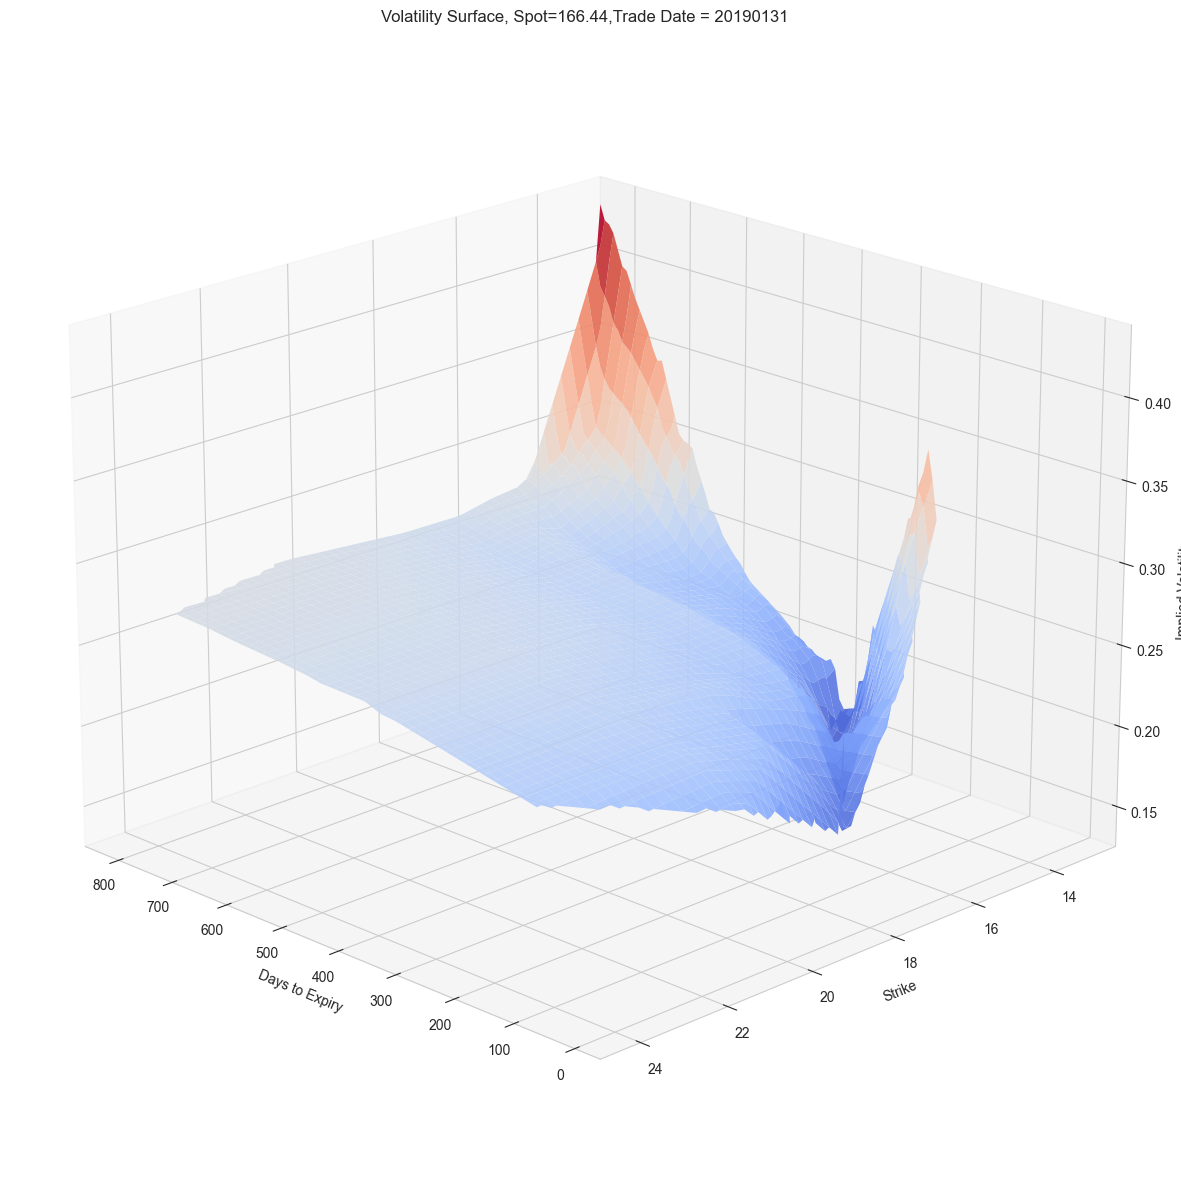

In [17]:
sufrace_genrator.plot_surface(elev=20,azim=135)

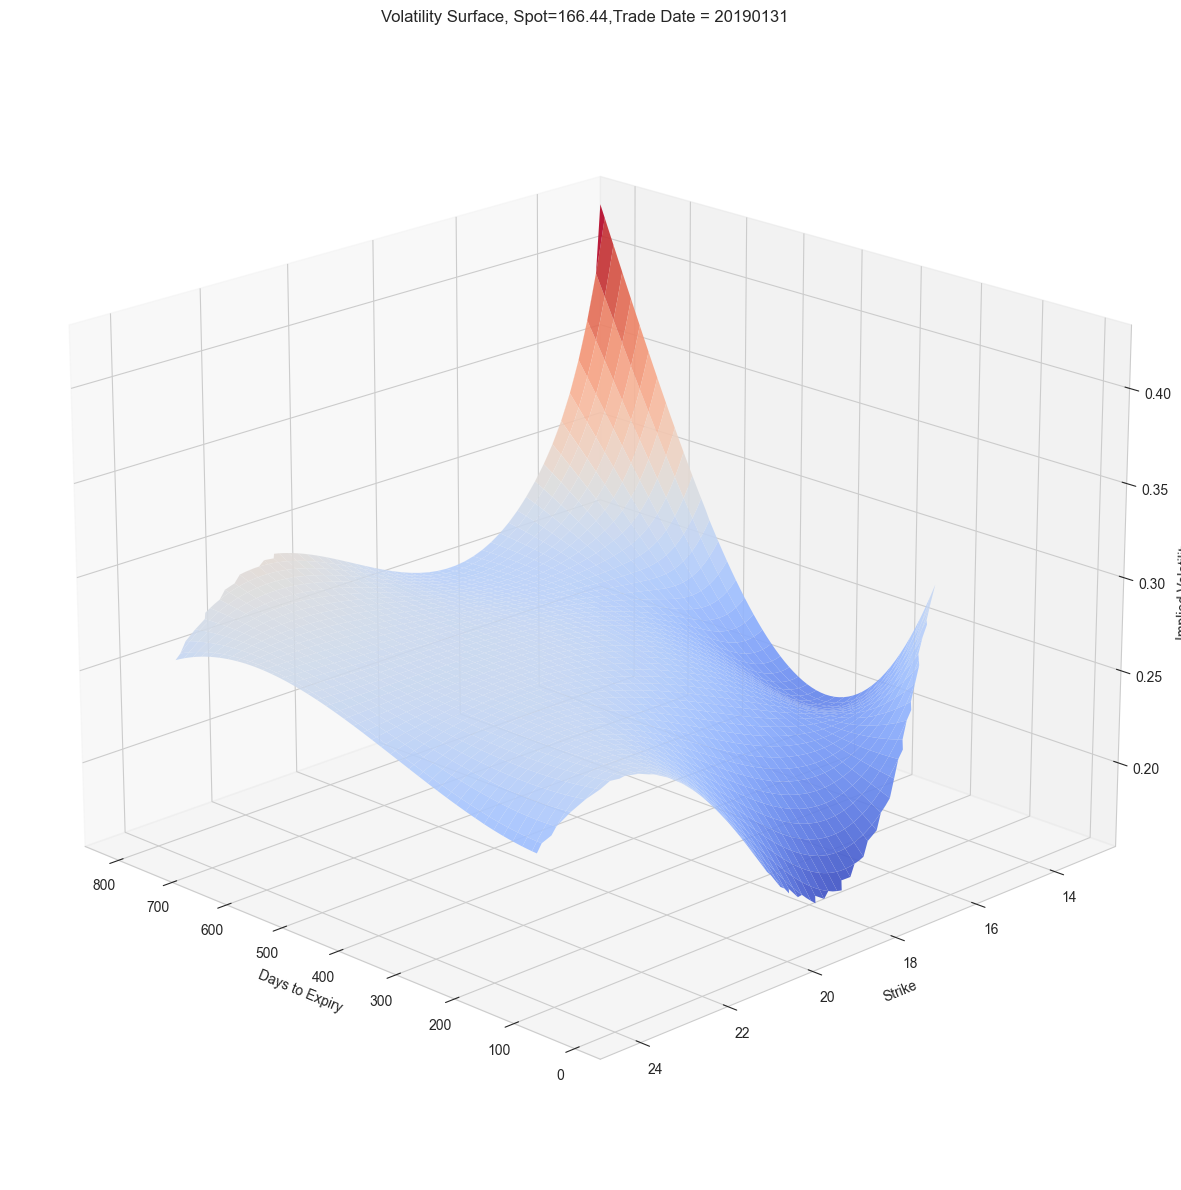

In [36]:
sufrace_genrator_b.plot_surface(elev=20,azim=135)

In [18]:
sufrace_genrator.exp_dict.keys()

dict_keys([np.int64(20131115), np.int64(20131122), np.int64(20131129), np.int64(20131206), np.int64(20131220), np.int64(20140117), np.int64(20140221), np.int64(20140417), np.int64(20140718), np.int64(20150116), np.int64(20160115)])

In [19]:
sufrace_genrator.exp_dict

{np.int64(20131115): np.float64(0.20936956903608547),
 np.int64(20131122): np.float64(0.24550758155857372),
 np.int64(20131129): np.float64(0.2818724087145114),
 np.int64(20131206): np.float64(0.3140543535541282),
 np.int64(20131220): np.float64(0.37379944809651644),
 np.int64(20140117): np.float64(0.4652293586655764),
 np.int64(20140221): np.float64(0.5588638180480892),
 np.int64(20140417): np.float64(0.6824612990181452),
 np.int64(20140718): np.float64(0.8456172261435341),
 np.int64(20150116): np.float64(1.101679912740986),
 np.int64(20160115): np.float64(1.486007798795885)}

In [20]:
np.sort(np.unique(sufrace_genrator.known_x))

array([0.20936957, 0.24550758, 0.28187241, 0.31405435, 0.37379945,
       0.46522936, 0.55886382, 0.6824613 , 0.84561723, 1.10167991,
       1.4860078 ])

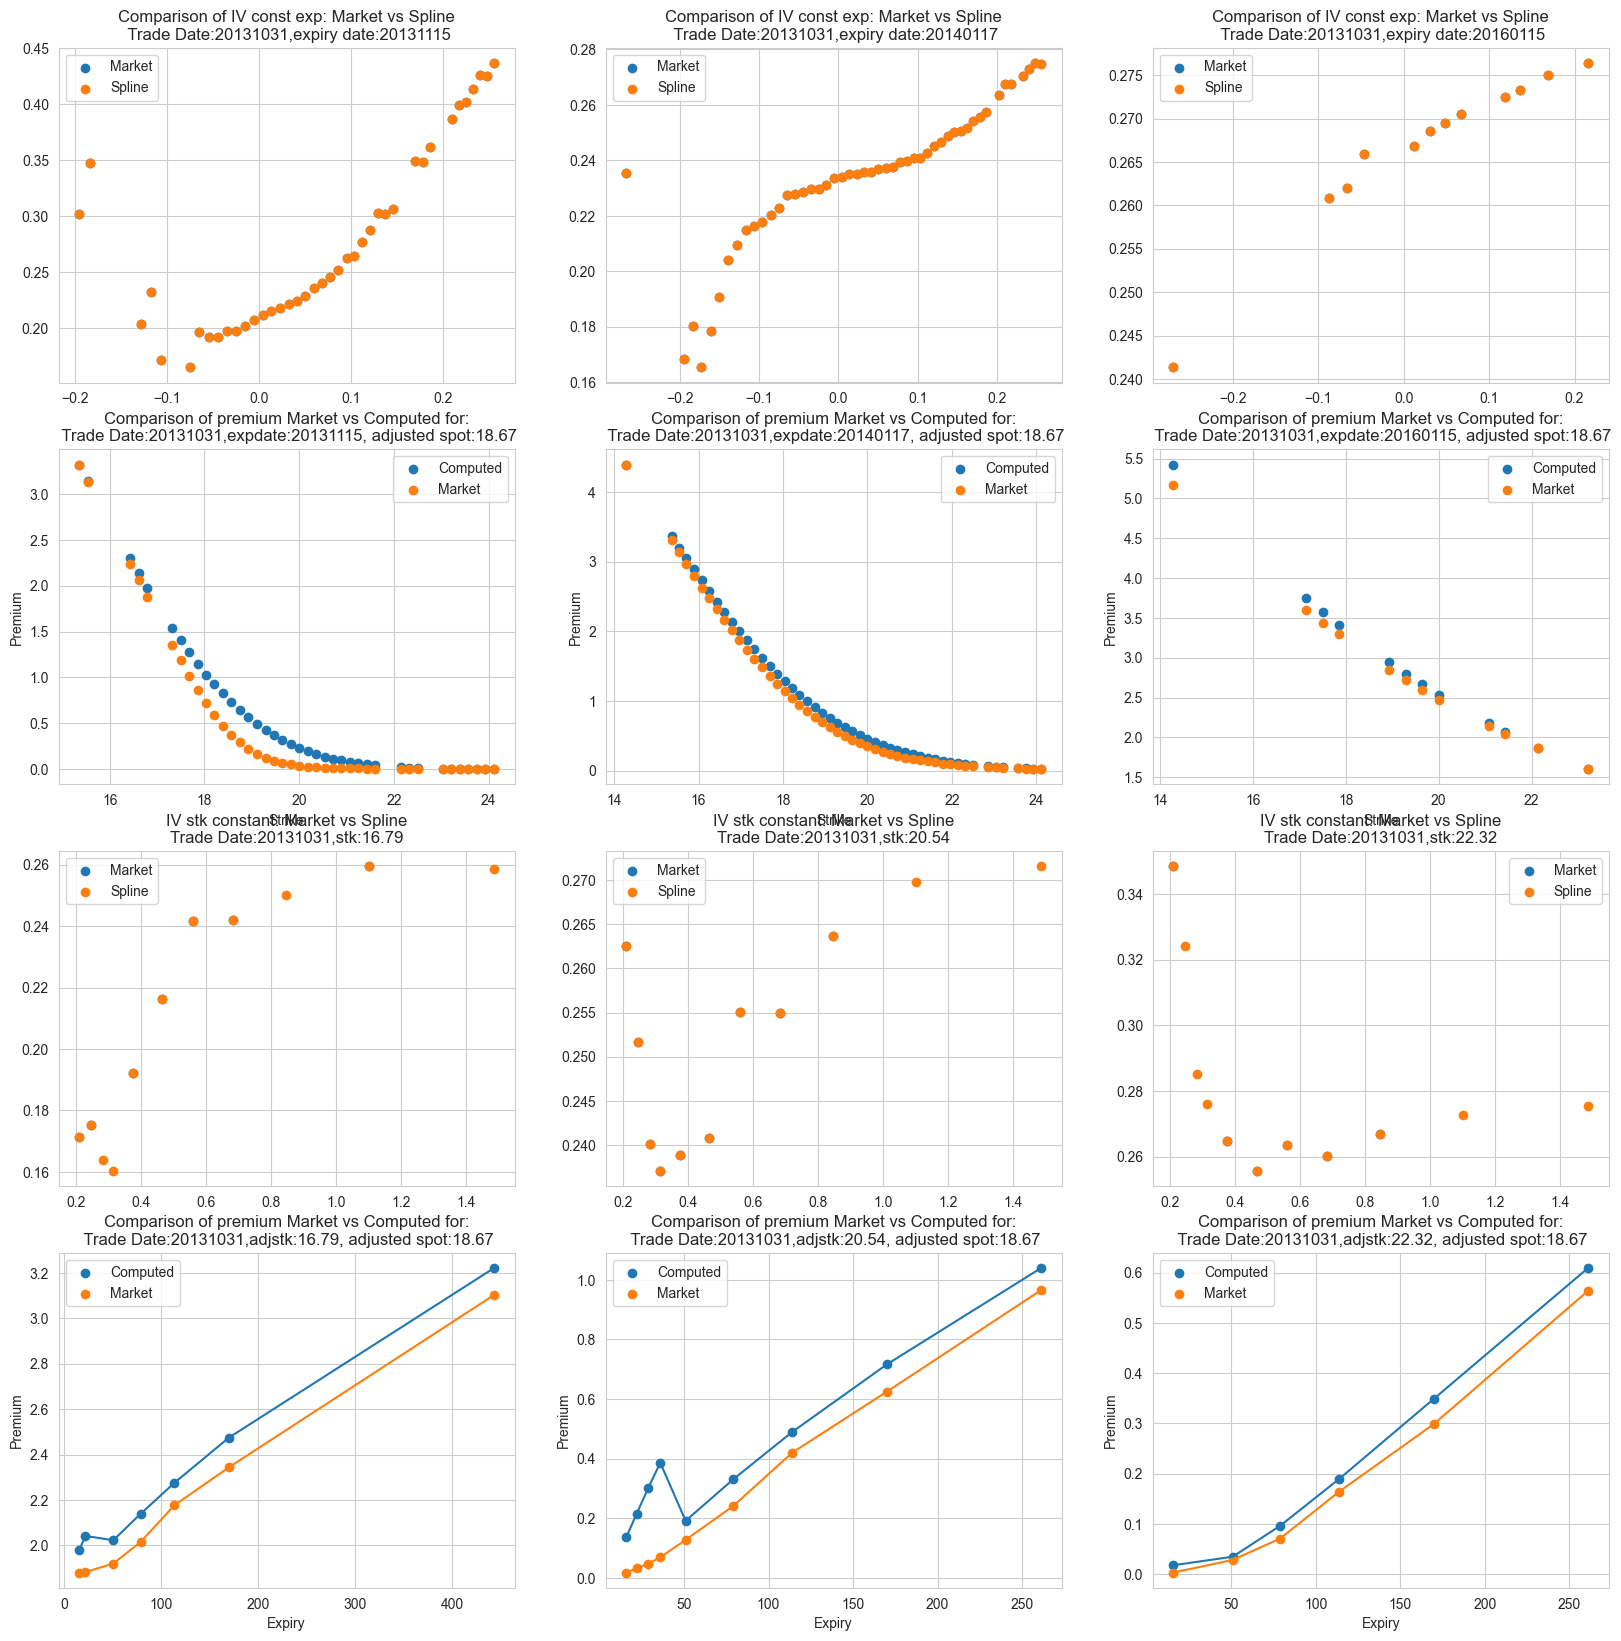

In [21]:
sufrace_genrator.plot_simulation_results()

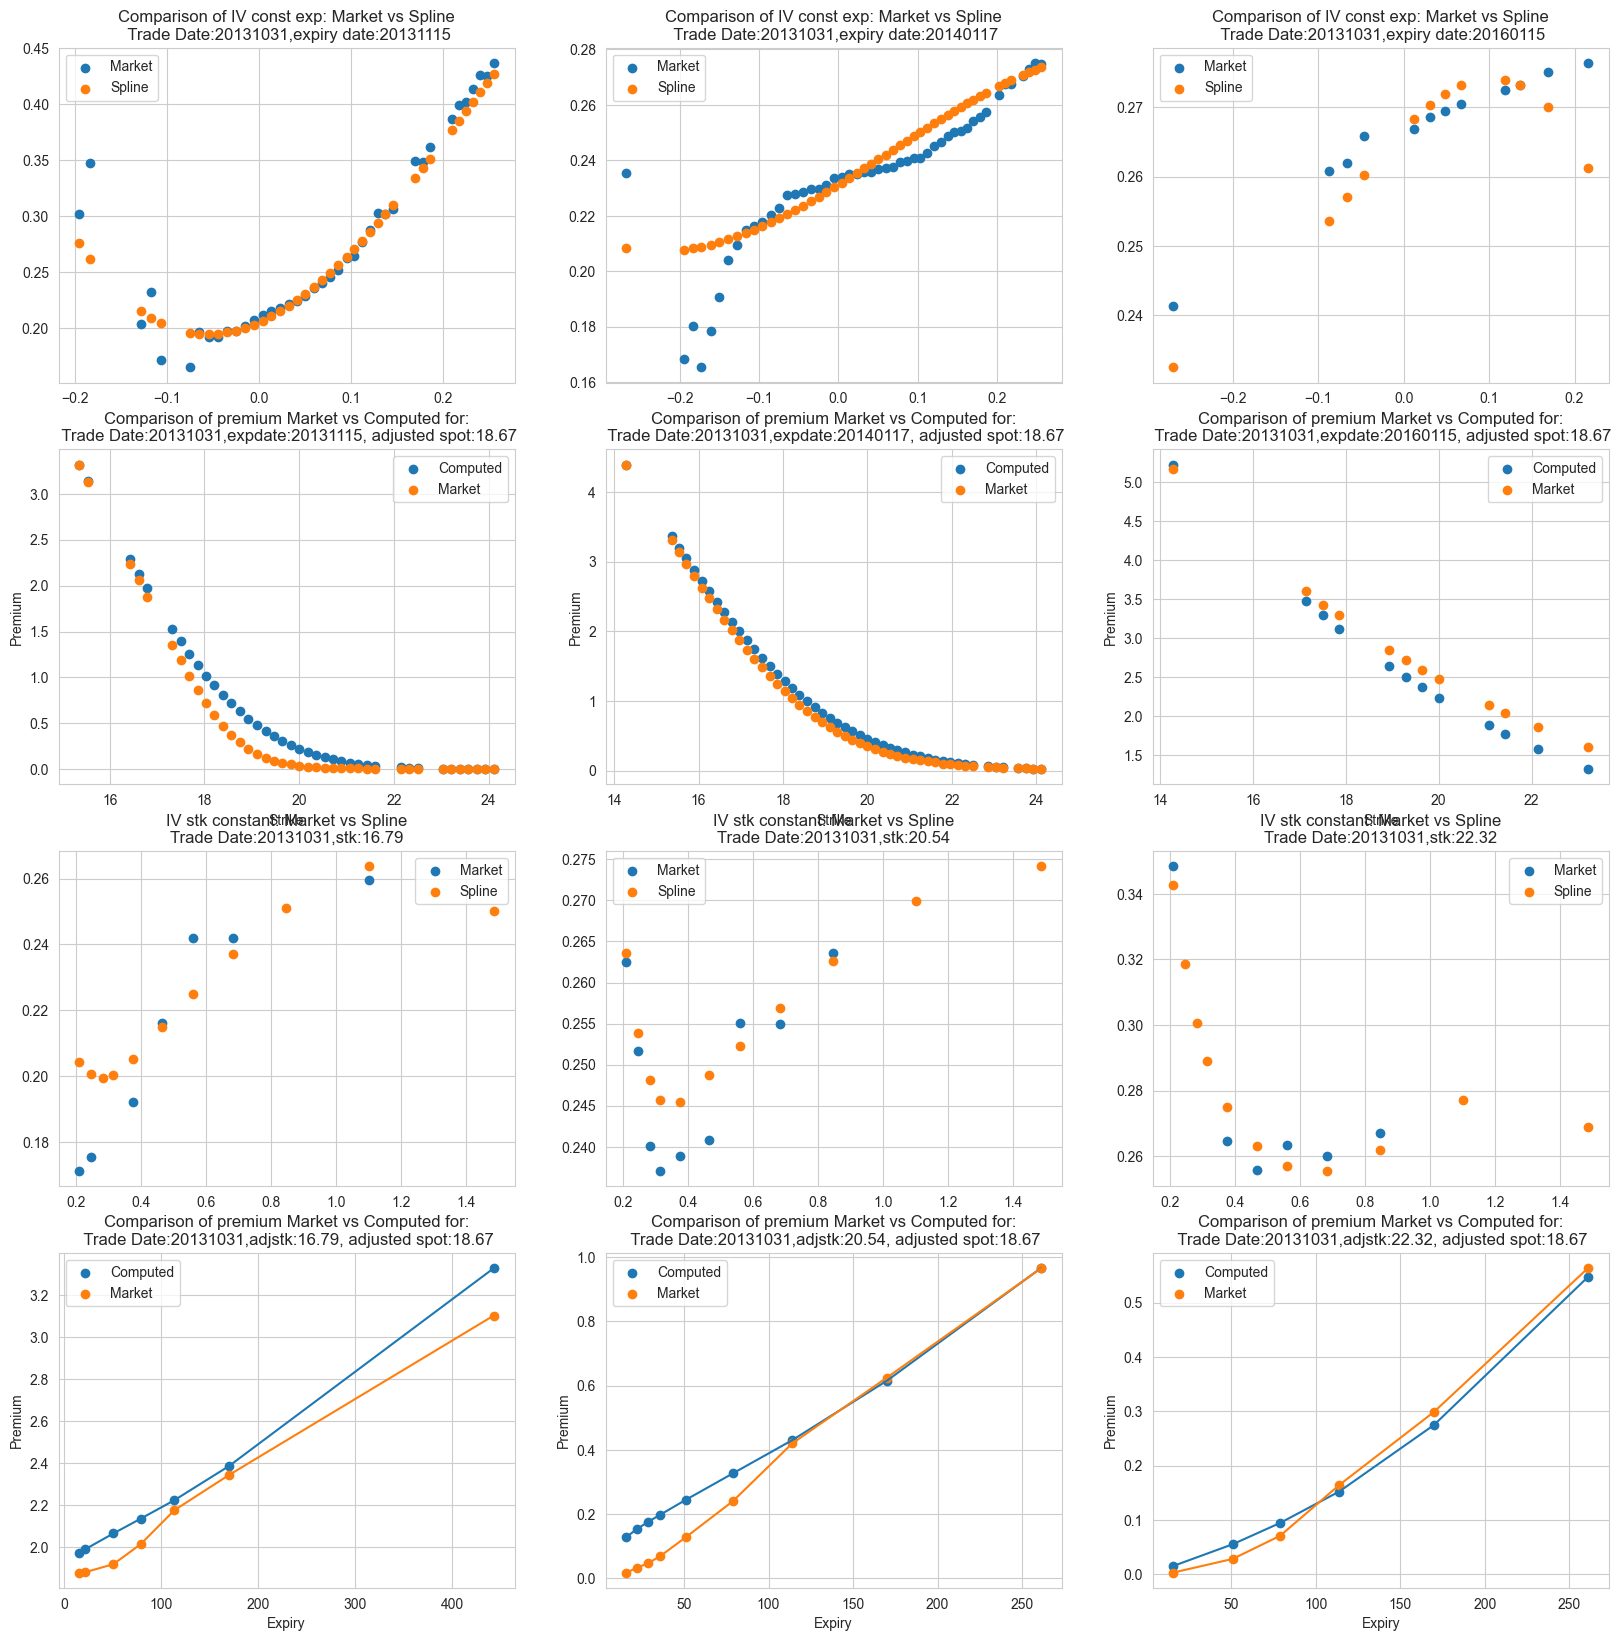

In [37]:
sufrace_genrator_b.plot_simulation_results()

In [38]:
sufrace_genrator.data

,TradeDate,AdjExpiry,CallPut,ImpliedVolatility,Spot,AdjSpot,Strike,AdjStrike,risk_free_rate,time_to_exp,days_to_expiry,px,AbsMoneyness
155,20131031,20150116,c,0.218882,522.7,18.67,370.0,13.21,0.000900,1.213699,443,5.6010,70.755222
162,20131031,20150116,c,0.224267,522.7,18.67,375.0,13.39,0.000900,1.213699,443,5.4535,71.719336
168,20131031,20150116,c,0.229048,522.7,18.67,380.0,13.57,0.000900,1.213699,443,5.3090,72.683449
181,20131031,20140417,c,0.160603,522.7,18.67,390.0,13.93,0.000767,0.465753,170,4.7470,74.611676
183,20131031,20150116,c,0.238212,522.7,18.67,390.0,13.93,0.000900,1.213699,443,5.0325,74.611676
...,...,...,...,...,...,...,...,...,...,...,...,...,...
776,20131031,20140417,c,0.266962,522.7,18.67,670.0,23.93,0.000767,0.465753,170,0.1535,128.173540
778,20131031,20150116,c,0.275497,522.7,18.67,670.0,23.93,0.000900,1.213699,443,0.7465,128.173540
780,20131031,20131115,c,0.436922,522.7,18.67,675.0,24.11,0.000300,0.043836,16,0.0015,129.137654
784,20131031,20140117,c,0.274755,522.7,18.67,675.0,24.11,0.000392,0.216438,79,0.0230,129.137654


In [39]:
valid_px = sufrace_genrator.data[sufrace_genrator.data.px>0].px.min()
valid_px

0.0015